In [111]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [112]:
X = np.array([1, 3, 4, 6, 7]) # Years of experience
y = np.array([15, 35, 45, 65, 70]) # Salary (in thousands)

<Axes: >

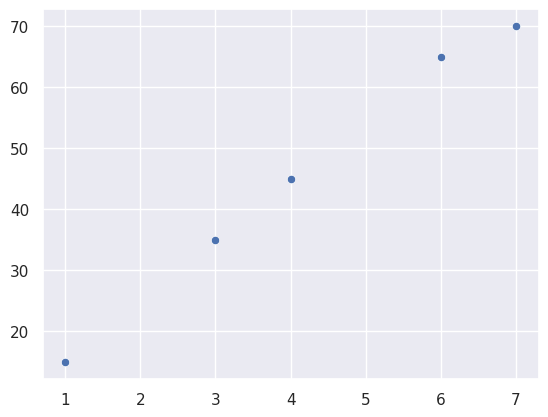

In [113]:
sns.scatterplot(x=X, y=y)

# Prediction Function

In [114]:
def make_prediction(X, y, w, b):
    m = X.shape[0]

    pred_list = np.zeros((m, ))

    for i in range(m):
        pred_list[i] = w * X[i] + b

    return pred_list

[0. 0. 0. 0. 0.]


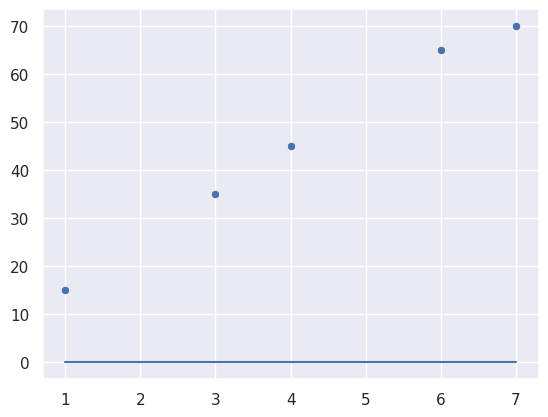

In [115]:
predictions = make_prediction(X, y, 0, 0)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

[1. 3. 4. 6. 7.]


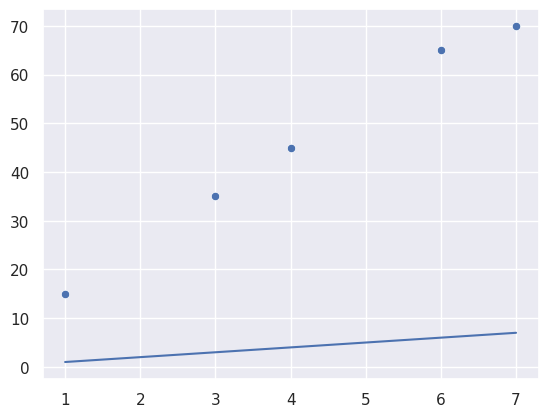

In [116]:
predictions = make_prediction(X, y, 1, 0)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

[ 8. 18. 23. 33. 38.]


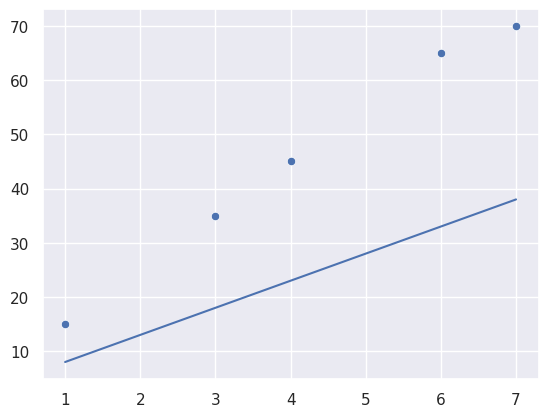

In [117]:
predictions = make_prediction(X, y, 5, 3)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

[15. 35. 45. 65. 75.]


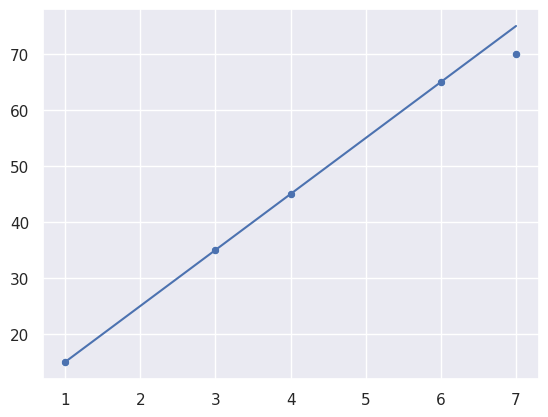

In [118]:
predictions = make_prediction(X, y, 10, 5)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

# Cost Funtion

In [119]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    cost = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        error_sq = error ** 2
        cost += error_sq

    cost = cost / (2*m)
    return cost

# Visualizing the Cost

[0. 0. 0. 0. 0.]


Text(0.5, 1.0, 'COST: 1260.0, for w = 0.0 and b = 0.0')

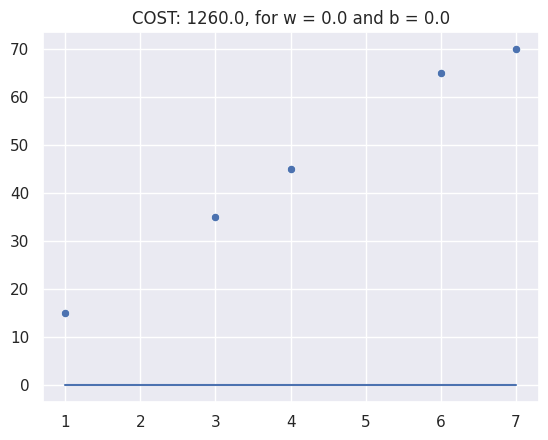

In [120]:
w = 0.0
b = 0.0

prediction = make_prediction(X, y, w=w, b=b)
print(prediction)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction)



plt.title(f"COST: {compute_cost(X, y, w=w, b=b)}, for w = {w} and b = {b}")

[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'COST: 2.5, for w = 10.0 and b = 5.0')

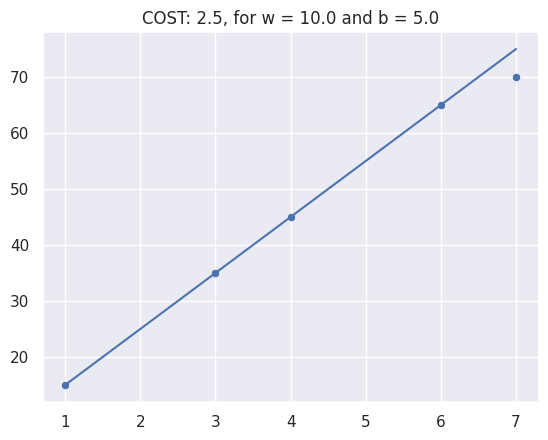

In [121]:
w = 10.0
b = 5.0


prediction = make_prediction(X, y, w=w, b=b)
print(prediction)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction)


plt.title(f"COST: {compute_cost(X, y, w=w, b=b)}, for w = {w} and b = {b}")

Text(0, 0.5, 'J(w)')

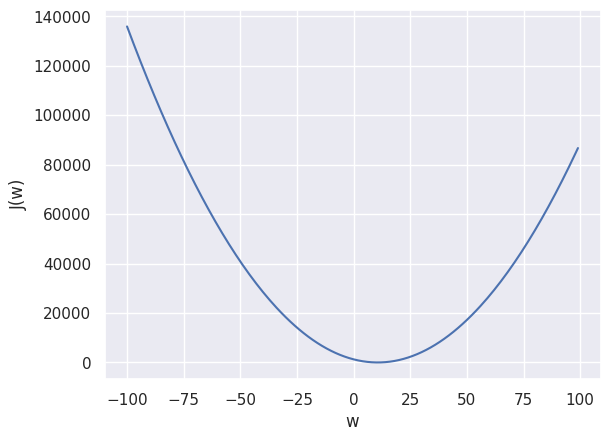

In [122]:
w = []
cost = []

for i in range(-100, 100):
    cost_i = compute_cost(X, y, w=i, b=0)
    w.append(i)
    cost.append(cost_i)


plt.plot(w, cost)
plt.xlabel("w")
plt.ylabel('J(w)')

# Gradient Descent

In [123]:
def calculate_gradient(X, y, w, b):
    m = X.shape[0]

    dj_dw = 0.0
    dj_db = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + error

    dj_dw = dj_dw / m
    dj_db = dj_db / m


    return dj_dw, dj_db



In [124]:
calculate_gradient(X, y, w=3, b=0)

(np.float64(-169.4), np.float64(-33.4))

In [125]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):


    w = w_input
    b = b_input

    cost_memo = []
    interation = []

    for i in range(max_iter):

        dj_dw, dj_db = calculate_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        cost_memo.append(cost)
        interation.append(i)

        if i%100 == 0:
            print(f"iteration : {i} w : {w: 0.4f}, b : {b: 0.4f}, dj_dw : {dj_dw: 0.4f}, dj_db : {dj_db: 0.4f}, cost : {cost: 0.4f}")

    return w, b, cost_memo, interation

In [126]:
w, b, memo, iter = gradient_descent(X, y, w_input=0, b_input=0, max_iter=10000, alpha=0.01)

iteration : 0 w :  2.3600, b :  0.4600, dj_dw : -236.0000, dj_db : -46.0000, cost :  748.3679
iteration : 100 w :  10.1075, b :  2.7989, dj_dw :  0.1433, dj_db : -0.7509, cost :  2.6083
iteration : 200 w :  9.9777, b :  3.4793, dj_dw :  0.1175, dj_db : -0.6157, cost :  2.1274
iteration : 300 w :  9.8712, b :  4.0372, dj_dw :  0.0964, dj_db : -0.5049, cost :  1.8041
iteration : 400 w :  9.7838, b :  4.4947, dj_dw :  0.0790, dj_db : -0.4140, cost :  1.5866
iteration : 500 w :  9.7122, b :  4.8699, dj_dw :  0.0648, dj_db : -0.3395, cost :  1.4404
iteration : 600 w :  9.6535, b :  5.1775, dj_dw :  0.0531, dj_db : -0.2784, cost :  1.3421
iteration : 700 w :  9.6053, b :  5.4297, dj_dw :  0.0436, dj_db : -0.2283, cost :  1.2760
iteration : 800 w :  9.5659, b :  5.6366, dj_dw :  0.0357, dj_db : -0.1872, cost :  1.2316
iteration : 900 w :  9.5335, b :  5.8062, dj_dw :  0.0293, dj_db : -0.1535, cost :  1.2017
iteration : 1000 w :  9.5069, b :  5.9453, dj_dw :  0.0240, dj_db : -0.1259, cost :  1

In [127]:
print(w, b)

9.385964914404349 6.5789473572963


[15.96491227 34.7368421  44.12280701 62.89473684 72.28070176]


Text(0.5, 1.0, 'COST: 1.1403508771929785, for w = 9.385964914404349 and b = 6.5789473572963')

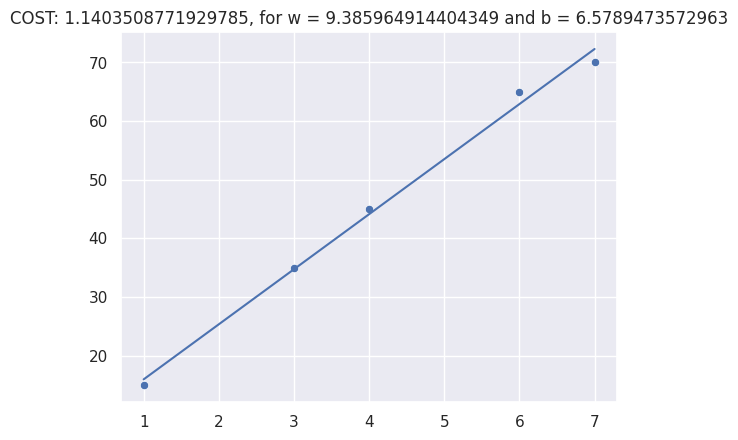

In [128]:
prediction = make_prediction(X, y, w=w, b=b)
print(prediction)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction)


plt.title(f"COST: {compute_cost(X, y, w=w, b=b)}, for w = {w} and b = {b}")

In [129]:
# Experience === 2 Years

x = 2
prediction = w * x + b
print(prediction)

25.350877186105


In [130]:
X = np.array([1, 3, 4, 6, 7]) # Years of experience
y = np.array([15, 35, 45, 65, 75]) # Salary (in thousands)

In [131]:
w, b, memo, iter = gradient_descent(X, y, w_input=-100, b_input=-100, max_iter=10000, alpha=0.01)

iteration : 0 w : -71.1700, b : -94.3300, dj_dw : -2883.0000, dj_db : -567.0000, cost :  111929.3269
iteration : 100 w :  22.6617, b : -61.3284, dj_dw :  2.5151, dj_db : -13.1754, cost :  451.9775
iteration : 200 w :  20.3827, b : -49.3897, dj_dw :  2.0624, dj_db : -10.8039, cost :  303.9148
iteration : 300 w :  18.5139, b : -39.5999, dj_dw :  1.6912, dj_db : -8.8593, cost :  204.3557
iteration : 400 w :  16.9814, b : -31.5723, dj_dw :  1.3868, dj_db : -7.2647, cost :  137.4111
iteration : 500 w :  15.7248, b : -24.9895, dj_dw :  1.1372, dj_db : -5.9571, cost :  92.3968
iteration : 600 w :  14.6944, b : -19.5916, dj_dw :  0.9325, dj_db : -4.8849, cost :  62.1286
iteration : 700 w :  13.8494, b : -15.1653, dj_dw :  0.7646, dj_db : -4.0056, cost :  41.7760
iteration : 800 w :  13.1566, b : -11.5357, dj_dw :  0.6270, dj_db : -3.2846, cost :  28.0907
iteration : 900 w :  12.5884, b : -8.5594, dj_dw :  0.5142, dj_db : -2.6934, cost :  18.8885
iteration : 1000 w :  12.1225, b : -6.1188, dj_d

In [132]:
print(w, b)

10.000000037263751 4.999999804793351


[14.99999984 34.99999992 44.99999995 65.00000003 75.00000007]


Text(0.5, 1.0, 'COST: 3.914780948517316e-15, for w = 10.000000037263751 and b = 4.999999804793351')

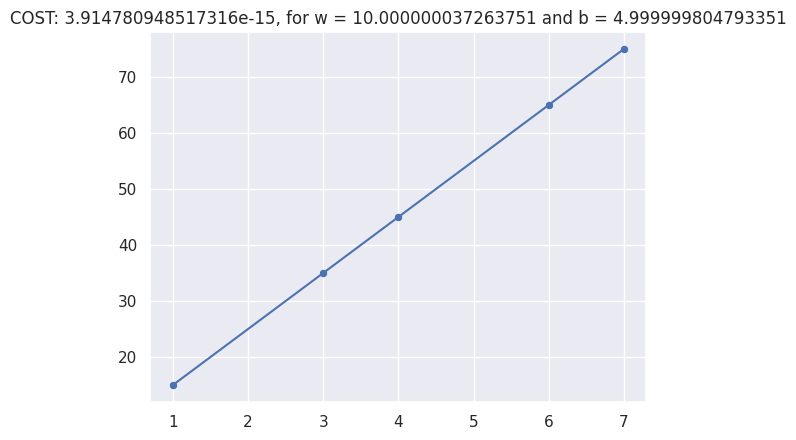

In [133]:
prediction = make_prediction(X, y, w=w, b=b)
print(prediction)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction)


plt.title(f"COST: {compute_cost(X, y, w=w, b=b)}, for w = {w} and b = {b}")

In [134]:
# Experience === 2 Years

x = 2
prediction = w * x + b
print(prediction)

24.999999879320853


Text(0, 0.5, 'cost')

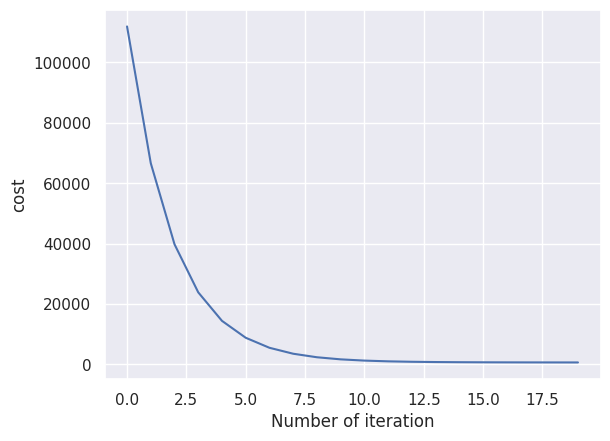

In [135]:
plt.plot(iter[:20], memo[:20])
plt.xlabel("Number of iteration")
plt.ylabel("cost")